In [ ]:
#librerías necesarias, semilla para reproducir resultados y device
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

torch.manual_seed(11)
np.random.seed(11)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
#parámetros
H0 = 0.7
Omega_m0 = 0.25
z_min, z_max = 0.0, 1.0

In [ ]:
#funciones auxiliares
def z_to_lna(z):
    z = np.asarray(z, dtype=float)
    return np.log(1.0/(1.0+z))

def lna_to_z(lna):
    lna = np.asarray(lna, dtype=float)
    return 1.0/np.exp(lna) - 1.0

def hubble_squared_z_np(z, Omega_m0, w, H0):
    z = np.asarray(z, dtype=float)
    return H0**2 * (Omega_m0*(1+z)**3 + (1-Omega_m0)*(1+z)**(3*(1+w)))

def Omega_m_of_z_np(z, Omega_m0, w, H0):
    H2 = hubble_squared_z_np(z, Omega_m0, w, H0)
    return (Omega_m0*(1+z)**3)/(H2/H0**2)

def hubble_squared_z_torch(z_tensor, Omega_m0, w, H0):
    return H0**2 * (Omega_m0 * (1 + z_tensor)**3 + (1 - Omega_m0) * (1 + z_tensor)**(3 * (1 + w)))

def Omega_m_of_z_torch(z_tensor, Omega_m0, w, H0):
    H2 = hubble_squared_z_torch(z_tensor, Omega_m0, w, H0)
    return (Omega_m0 * (1 + z_tensor)**3) / (H2 / (H0**2))

def compute_alpha(z, Omega_m0, w, H0):
    if abs(w - 1.0) > 1e-10:
        alpha0 = (3.0 / (5.0 - w)) / (1.0 - w)
    else:
        alpha0 = 0.6
    if abs(1.0 - 6.0*w/5.0) > 1e-10:
        alpha1 = (3*(1-w)*(1-3*w/2)) / (125*(1-6*w/5)**3)
    else:
        alpha1 = 0.0
    Om_z = Omega_m_of_z_np(z, Omega_m0, w, H0)
    return alpha0 + alpha1*(1-Om_z)

In [ ]:
#solución con odeint
def reference_solution(z_array, Omega_m0, w, f_nu, H0):
    z_array = np.asarray(z_array, dtype=float).reshape(-1)

    def rhs(lna, y):
        ln_delta, f = y
        z = np.exp(-lna) - 1.0
        Om_z = Omega_m_of_z_np(z, Omega_m0, w, H0)
        dln_delta_dlna = f
        df_dlna = -f**2 - (0.5 - 1.5*w*(1.0 - Om_z))*f + 1.5*Om_z*(1.0 - f_nu)
        return [dln_delta_dlna, df_dlna]

    Omega_DE = 1.0 - Omega_m0
    alpha_at_z0 = compute_alpha(0.0, Omega_m0, w, H0)
    mu = 1 - 0.8*Omega_DE*f_nu + 3.9*f_nu**2 - 9.8*f_nu**3
    f0 = mu*(Omega_m0**alpha_at_z0)
    y0 = [0.0, f0]

    lna_req = z_to_lna(z_array).reshape(-1)
    if np.allclose(lna_req, 0.0):
        return np.ones_like(lna_req)

    lna_min = float(np.min(lna_req))
    order_desc = np.argsort(-lna_req)
    t_eval_desc = lna_req[order_desc]

    sol = solve_ivp(
        rhs,
        t_span=(0.0, lna_min),
        y0=y0,
        t_eval=t_eval_desc,
        method='LSODA',
        rtol=1e-7,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp falló: {sol.message}")

    ln_delta_eval_desc = sol.y[0]

    inv_order = np.empty_like(order_desc)
    inv_order[order_desc] = np.arange(order_desc.size)

    ln_delta_out = ln_delta_eval_desc[inv_order]
    return np.exp(ln_delta_out)

In [ ]:
#arquitectura de la red
class NeutrinoPINN(nn.Module):
    def __init__(self, layers=[1,128,128,64,2]):
        super().__init__()
        modules=[]
        for i in range(len(layers)-1):
            modules.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:
                modules.append(nn.Tanh())
        self.net = nn.Sequential(*modules)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, lna):
        return self.net(lna)

def reset_weights(m):
    if isinstance(m, nn.Linear):
        m.reset_parameters()

In [ ]:
#función de pérdida para y''=2y
def loss_fn_y2(model, x):
    y = model(x)
    y_x = grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    y_xx = grad(y_x, x, grad_outputs=torch.ones_like(y_x), create_graph=True)[0]
    f = y_xx - 2*y
    return torch.mean(f**2)

def train_pinn_y2(max_epochs=2000, lr=1e-3):
    x_train = torch.linspace(0,1,200).view(-1,1).to(device)
    x_train.requires_grad_(True)
    y0_val = torch.tensor([[1.0]], dtype=torch.float32).to(device)
    yp0_val = torch.tensor([[0.0]], dtype=torch.float32).to(device)
    x_bc_0 = torch.tensor([[0.0]], dtype=torch.float32).to(device).requires_grad_(True)

    model = NeutrinoPINN(layers=[1,128,128,64,1]).to(device)
    model.apply(reset_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    #historial de pérdida
    hist_loss = []

    for ep in range(max_epochs):
        optimizer.zero_grad()
        loss = loss_fn_y2(model, x_train)
        y_pred0 = model(x_bc_0)
        y_x0 = grad(y_pred0, x_bc_0, grad_outputs=torch.ones_like(y_pred0), create_graph=True)[0]
        loss_bc = (y_pred0 - y0_val)**2 + (y_x0 - yp0_val)**2
        total_loss = loss + 500*loss_bc
        total_loss.backward()
        optimizer.step()

        hist_loss.append(total_loss.item())

    # Evaluación
    x_np = x_train.detach().cpu().numpy().flatten()
    with torch.no_grad():
        y_pred = model(x_train).cpu().numpy().flatten()
    y_exact = np.cosh(np.sqrt(2)*x_np)
    r2 = r2_score(y_exact, y_pred)

    # Gráfica de comparación
    plt.figure(figsize=(10, 6))

    plt.plot(x_np, y_exact, 'k-', lw=2, label='Solución exacta')
    plt.plot(x_np, y_pred, 'r--', lw=2, label='PINN')
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y(x)', fontsize=12)
    plt.title(f'Validación: y\'\' = 2y | R² = {r2:.6f}', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"R² = {r2:.6f}")
    return model

#métricas
def compute_r2_metrics(model, lna_points, z_points, Omega_m0, w, f_nu, H0):
    model.eval()
    lna_points = np.asarray(lna_points, dtype=np.float32).reshape(-1,1)
    z_points = np.asarray(z_points, dtype=float).reshape(-1)

    with torch.no_grad():
        lna_t = torch.as_tensor(lna_points, dtype=torch.float32, device=device)
        out = model(lna_t)
        ln_delta_pred = out[:,0].detach().cpu().numpy()
        delta_pred = np.exp(ln_delta_pred)

    delta_ref = reference_solution(z_points, Omega_m0, w, f_nu, H0)
    r2_delta = r2_score(delta_ref, delta_pred)
    model.train()
    return r2_delta

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/(y_true + 1e-10)))*100
    return {'mse':mse,'rmse':rmse,'mae':mae,'r2':r2,'mape':mape}

In [ ]:
#entrenamiento de la PINN
def train_neutrino_pinn_for_scenario(w_scenario, f_nu_scenario, num_epochs=2500, w_bc=500.0, eval_every=200):
    n_colloc = 1000
    z_colloc = np.random.uniform(z_min, z_max, size=(n_colloc,1))
    lna_colloc = z_to_lna(z_colloc)
    lna_colloc_t = torch.tensor(lna_colloc, dtype=torch.float32, requires_grad=True).to(device)

    # Condiciones iniciales
    lna_bc = torch.tensor([[0.0]], dtype=torch.float32).to(device)
    ln_delta_bc = torch.tensor([[0.0]], dtype=torch.float32).to(device)

    alpha0 = compute_alpha(0, Omega_m0, w_scenario, H0)
    Omega_DE = 1-Omega_m0
    mu = 1 - 0.8*Omega_DE*f_nu_scenario + 3.9*f_nu_scenario**2 - 9.8*f_nu_scenario**3
    f0 = mu*(Omega_m0**alpha0)
    f_bc = torch.tensor([[f0]], dtype=torch.float32).to(device)

    model = NeutrinoPINN().to(device)
    model.apply(reset_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    hist = {'r2': []}

    z_eval_r2 = np.linspace(z_min, z_max, 200)
    lna_eval_r2 = z_to_lna(z_eval_r2)

    print(f"\n{'='*60}\nEntrenando: w = {w_scenario}, f_ν = {f_nu_scenario}\n{'='*60}")

    for ep in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        out = model(lna_colloc_t)
        ln_delta_pred = out[:,0:1]
        f_pred = out[:,1:2]

        dln_delta_dlna = grad(ln_delta_pred, lna_colloc_t, grad_outputs=torch.ones_like(ln_delta_pred), create_graph=True)[0]
        df_dlna = grad(f_pred, lna_colloc_t, grad_outputs=torch.ones_like(f_pred), create_graph=True)[0]

        Om_z = Omega_m_of_z_torch(torch.exp(-lna_colloc_t)-1, Omega_m0, w_scenario, H0)

        R1 = dln_delta_dlna - f_pred
        R2 = df_dlna + f_pred**2 + (0.5 - 1.5*w_scenario*(1-Om_z))*f_pred - 1.5*Om_z*(1-f_nu_scenario)

        loss_pde = torch.mean(R1**2) + torch.mean(R2**2)

        out_bc = model(lna_bc)
        loss_bc = torch.mean((out_bc[:,0:1]-ln_delta_bc)**2) + torch.mean((out_bc[:,1:2]-f_bc)**2)

        total_loss = loss_pde + w_bc*loss_bc
        total_loss.backward()
        optimizer.step()

        if (ep+1) % eval_every == 0 or ep == num_epochs-1:
            r2_delta = compute_r2_metrics(model, lna_eval_r2, z_eval_r2, Omega_m0, w_scenario, f_nu_scenario, H0)
            hist['r2'].append((ep+1, r2_delta))
            print(f"Época {ep+1:4d} | Pérdida = {total_loss.item():.3e} | R² δ(z) = {r2_delta:.6f}")

    return model, hist

#gráfica para comparar soluciones
def plot_reference_vs_pinn(model, w, f_nu, Omega_m0, H0, label=''):
    model.eval()
    z_plot = np.linspace(z_min, z_max, 400)
    lna_plot = z_to_lna(z_plot).reshape(-1,1)

    with torch.no_grad():
        lna_t = torch.tensor(lna_plot, dtype=torch.float32, device=device)
        out = model(lna_t)
        ln_delta_pred = out[:,0].detach().cpu().numpy()
        delta_pred = np.exp(ln_delta_pred)

    delta_ref = reference_solution(z_plot, Omega_m0, w, f_nu, H0)

    met_delta = metrics(delta_ref, delta_pred)

    plt.figure(figsize=(10, 6))
    plt.plot(z_plot, delta_ref, 'k-', lw=2.5, label='Solución de referencia')
    plt.plot(z_plot, delta_pred, 'r--', lw=2.5, label='PINN')
    plt.xlabel('z', fontsize=13)
    plt.ylabel('δ(z)', fontsize=11)
    plt.title(f'{label}: w = {w}, f_ν = {f_nu} | R² = {met_delta["r2"]:.6f}',
              fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{label} - Métricas δ(z):")
    print(f"  R²   = {met_delta['r2']:.6f}")
    print(f"  RMSE = {met_delta['rmse']:.6e}")
    print(f"  MAE  = {met_delta['mae']:.6e}")
    print(f"  MAPE = {met_delta['mape']:.3f}%")

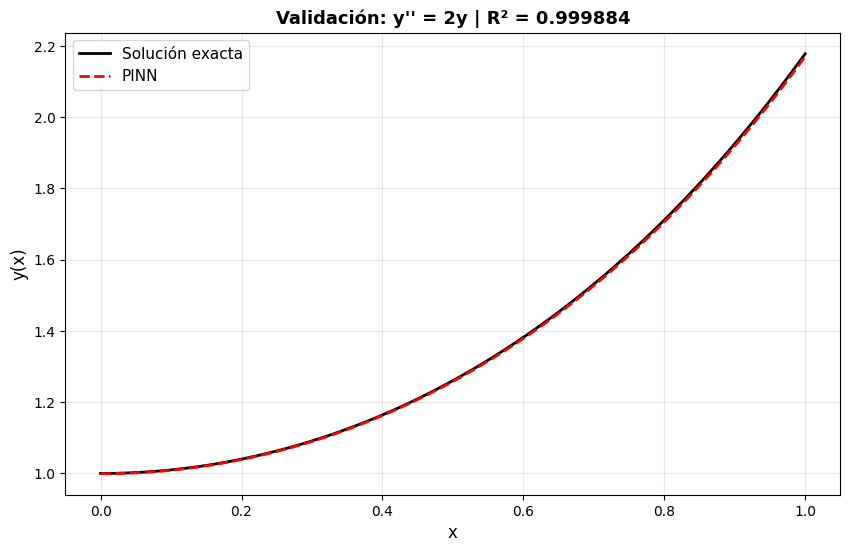

R² = 0.999884

Entrenando: w = -1.0, f_ν = 0.04
Época  200 | Pérdida = 4.493e-01 | R² δ(z) = 0.481265
Época  400 | Pérdida = 4.158e-01 | R² δ(z) = 0.619063
Época  600 | Pérdida = 3.942e-01 | R² δ(z) = 0.652230
Época  800 | Pérdida = 3.737e-01 | R² δ(z) = 0.674040
Época 1000 | Pérdida = 3.511e-01 | R² δ(z) = 0.687981
Época 1200 | Pérdida = 3.120e-01 | R² δ(z) = 0.692526
Época 1400 | Pérdida = 2.233e-01 | R² δ(z) = 0.731392
Época 1600 | Pérdida = 1.611e-01 | R² δ(z) = 0.807398
Época 1800 | Pérdida = 1.270e-01 | R² δ(z) = 0.850579
Época 2000 | Pérdida = 9.334e-02 | R² δ(z) = 0.886640
Época 2200 | Pérdida = 7.764e-02 | R² δ(z) = 0.900783
Época 2400 | Pérdida = 7.528e-02 | R² δ(z) = 0.922007
Época 2600 | Pérdida = 5.278e-02 | R² δ(z) = 0.930696
Época 2800 | Pérdida = 1.240e-01 | R² δ(z) = 0.945499
Época 3000 | Pérdida = 4.028e-02 | R² δ(z) = 0.948162


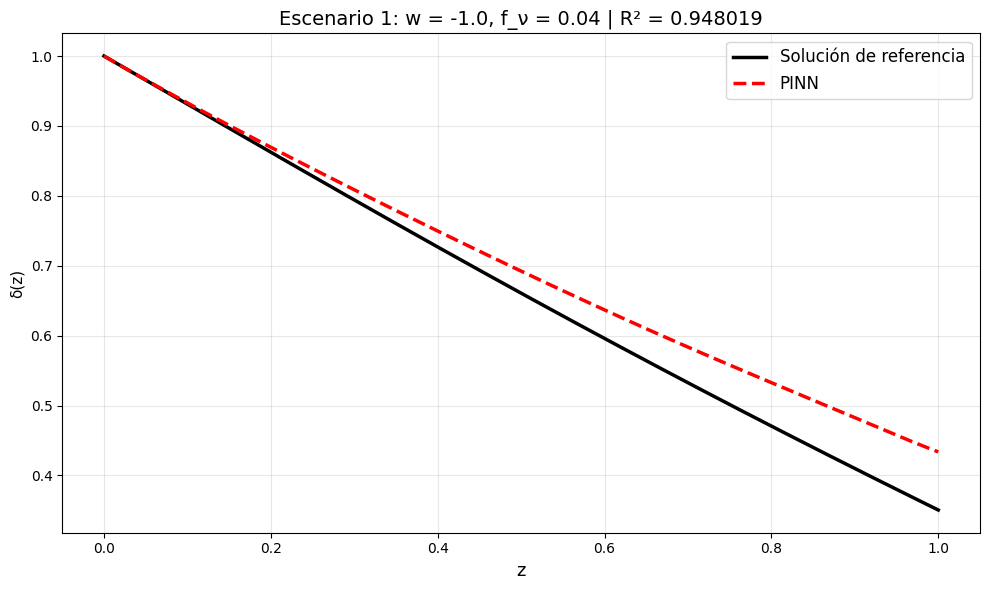


Escenario 1 - Métricas δ(z):
  R²   = 0.948019
  RMSE = 4.301590e-02
  MAE  = 3.449664e-02
  MAPE = 6.945%

Entrenando: w = -0.8, f_ν = 0.04
Época  200 | Pérdida = 3.270e-01 | R² δ(z) = 0.628051
Época  400 | Pérdida = 3.047e-01 | R² δ(z) = 0.707801
Época  600 | Pérdida = 2.875e-01 | R² δ(z) = 0.732884
Época  800 | Pérdida = 2.705e-01 | R² δ(z) = 0.750877
Época 1000 | Pérdida = 2.510e-01 | R² δ(z) = 0.762143
Época 1200 | Pérdida = 2.136e-01 | R² δ(z) = 0.771319
Época 1400 | Pérdida = 1.575e-01 | R² δ(z) = 0.797232
Época 1600 | Pérdida = 1.441e-01 | R² δ(z) = 0.861057
Época 1800 | Pérdida = 1.151e-01 | R² δ(z) = 0.832439
Época 2000 | Pérdida = 1.102e-01 | R² δ(z) = 0.840992
Época 2200 | Pérdida = 9.495e-02 | R² δ(z) = 0.860468
Época 2400 | Pérdida = 8.433e-02 | R² δ(z) = 0.876310
Época 2600 | Pérdida = 7.538e-02 | R² δ(z) = 0.890826
Época 2800 | Pérdida = 6.714e-02 | R² δ(z) = 0.901509
Época 3000 | Pérdida = 6.885e-02 | R² δ(z) = 0.913613


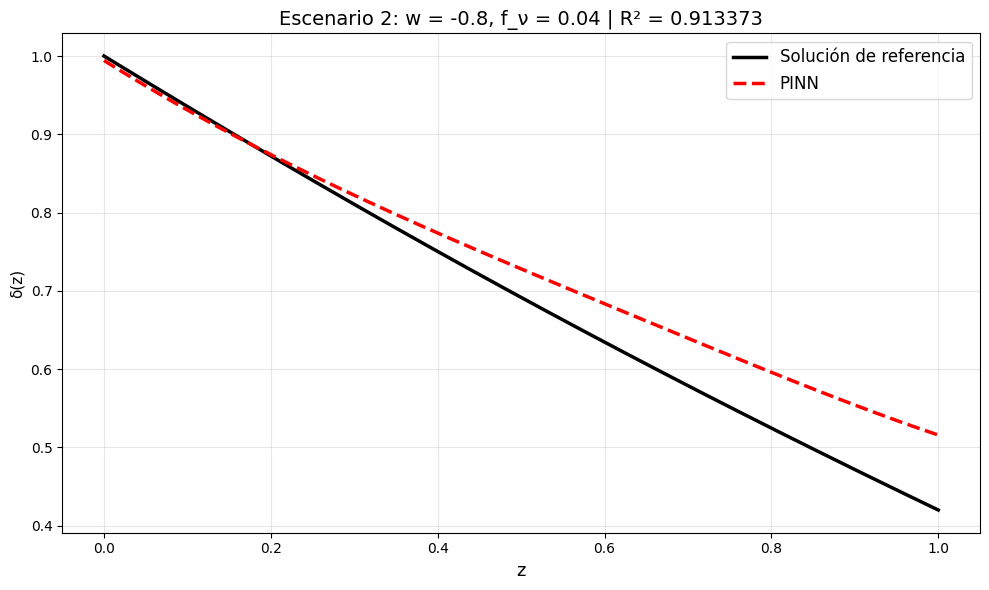


Escenario 2 - Métricas δ(z):
  R²   = 0.913373
  RMSE = 4.941380e-02
  MAE  = 3.911365e-02
  MAPE = 7.109%


In [ ]:
#escenarios para validar variando w y f_nu
scenarios = [
    {'w': -1.0, 'f_nu': 0.04, 'label':'Escenario 1'},
    {'w': -0.8, 'f_nu': 0.04,  'label':'Escenario 2'}
]

models = []
histories = []

#validación y''=2y
model_val = train_pinn_y2()

#entrenamiento y gráficos por escenario
for scen in scenarios:
    model_trained, hist = train_neutrino_pinn_for_scenario(
        scen['w'], scen['f_nu'], num_epochs=3000, w_bc=500.0, eval_every=200
    )
    models.append(model_trained)
    histories.append(hist)

    plot_reference_vs_pinn(model_trained, scen['w'], scen['f_nu'], Omega_m0, H0, label=scen['label'])